SOEN 471 Section UU<br>
Reza Mirsalari<br>
February 25, 2026<br>

# **Assignment 1** #

### **Task 1 – Data Preparation and Exploration (EDA)** ###

In [2]:
import pandas as pd

Load customer_churn.csv

In [3]:
customers = pd.read_csv('customer_churn.csv')

Dataset Structure

In [4]:
customers.columns

Index(['CustomerID', 'Age', 'Subscription_Length_Months', 'Watch_Time_Hours',
       'Number_of_Logins', 'Payment_Issues', 'Number_of_Complaints',
       'Resolution_Time_Days', 'Membership_Type', 'Payment_Method',
       'Preferred_Content_Type', 'Churn'],
      dtype='object')

Summary Statistics

In [5]:
customers.describe()

,CustomerID,Age,Subscription_Length_Months,Watch_Time_Hours,Number_of_Logins,Payment_Issues,Number_of_Complaints,Resolution_Time_Days,Churn
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.81900,18.218000,120.750899,30.984000,0.245000,4.552000,14.978000,0.793000
std,288.819436,14.99103,10.177822,38.583580,17.562237,0.430302,2.912349,8.394521,0.405358
min,1.000000,18.00000,1.000000,10.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,250.750000,31.00000,9.000000,93.630672,16.750000,0.000000,2.000000,7.000000,1.000000
50%,500.500000,44.00000,18.000000,122.085008,31.000000,0.000000,5.000000,15.000000,1.000000
75%,750.250000,56.00000,27.000000,147.273070,47.000000,0.000000,7.000000,22.000000,1.000000
max,1000.000000,69.00000,35.000000,227.988566,59.000000,1.000000,9.000000,29.000000,1.000000


Identify and handle missing values

In [11]:
customers.isna().sum()

CustomerID                    0
Age                           0
Subscription_Length_Months    0
Watch_Time_Hours              0
Number_of_Logins              0
Payment_Issues                0
Number_of_Complaints          0
Resolution_Time_Days          0
Membership_Type               0
Payment_Method                0
Preferred_Content_Type        0
Churn                         0
dtype: int64

there are no nulls, nothing to do

Histogram

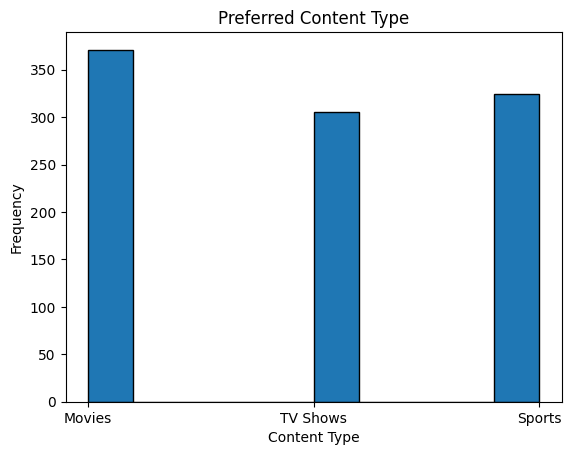

In [36]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist(customers.Preferred_Content_Type, edgecolor='black')


plt.xlabel('Content Type')
plt.ylabel('Frequency')
plt.title('Preferred Content Type')


plt.show()

Box Plots

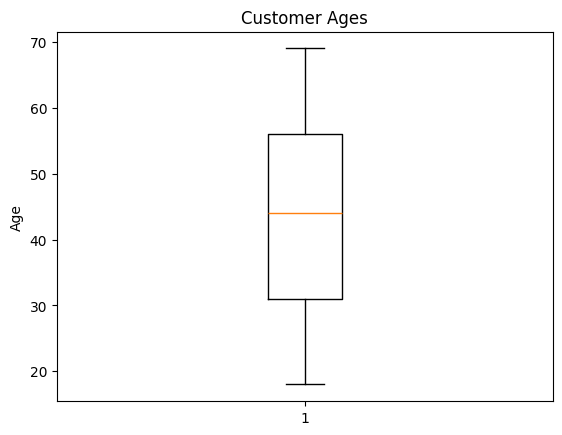

In [38]:
data = np.random.normal(100, 15, 200)

# Create a basic box plot
plt.boxplot(customers.Age)
plt.title("Customer Ages")
plt.ylabel("Age")
plt.show()

Correlation analysis

would be easier if all columns were numerical data. so lets encode

In [55]:
customers.Membership_Type.unique()

array(['Standard', 'Basic', 'Premium'], dtype=object)

In [57]:
customers.Payment_Method.unique()

array(['Debit', 'PayPal', 'Credit Card'], dtype=object)

In [58]:
customers.Preferred_Content_Type.unique()

array(['Movies', 'TV Shows', 'Sports'], dtype=object)

In [ ]:
customers.loc[customers['Membership_Type'] == 'Premium', 'Membership_Type'] = 2

In [45]:
num_cols = [
    'Age',
    'Subscription_Length_Months',
    'Watch_Time_Hours',
    'Number_of_Logins',
    'Payment_Issues',
    'Number_of_Complaints',
    'Resolution_Time_Days',
    'Churn'
]

# Compute correlation matrix
corr_matrix = customers[num_cols].corr()

corr_matrix

,Age,Subscription_Length_Months,Watch_Time_Hours,Number_of_Logins,Payment_Issues,Number_of_Complaints,Resolution_Time_Days,Churn
Age,1.000000,-0.018938,-0.020481,0.021817,0.034503,0.040649,0.004685,-0.010949
Subscription_Length_Months,-0.018938,1.000000,-0.058968,0.001856,0.002649,0.042708,0.032018,-0.018409
Watch_Time_Hours,-0.020481,-0.058968,1.000000,0.005315,-0.008800,0.020570,-0.073827,-0.105913
Number_of_Logins,0.021817,0.001856,0.005315,1.000000,0.027806,0.007982,-0.007607,0.027516
Payment_Issues,0.034503,0.002649,-0.008800,0.027806,1.000000,0.010991,-0.005711,0.239394
Number_of_Complaints,0.040649,0.042708,0.020570,0.007982,0.010991,1.000000,-0.005440,0.310561
Resolution_Time_Days,0.004685,0.032018,-0.073827,-0.007607,-0.005711,-0.005440,1.000000,0.151335
Churn,-0.010949,-0.018409,-0.105913,0.027516,0.239394,0.310561,0.151335,1.000000


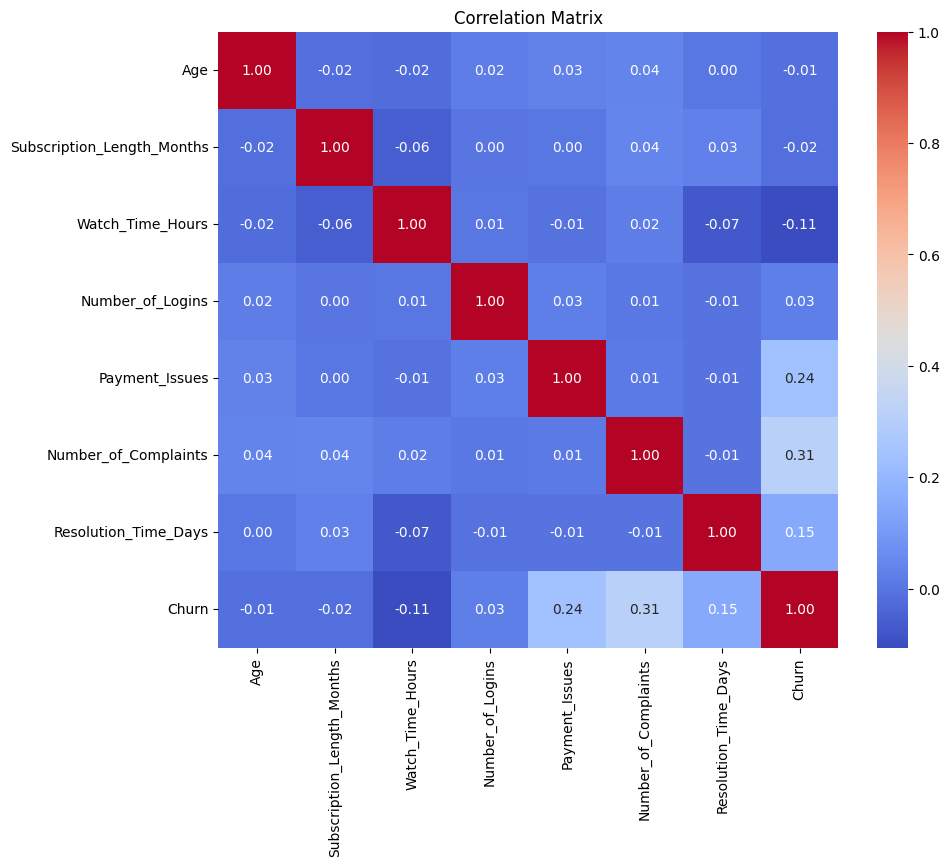

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

**Important patterns or anomalies observed**


### **Task 2 – Decision Tree Classifier** ###

Split the dataset into training and testing sets

In [52]:
from sklearn.model_selection import train_test_split

X = customers.drop(columns=['Churn', 'CustomerID'])
y = customers['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=471)

Train a Decision Tree Classifier

In [53]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)

ValueError: could not convert string to float: 'Premium'